PRACTICA 9:  Mediante el fichero Datos Pedidos.xlsx, cargar en un formulario de tkinter, 
solamente los pedidos segun el pais indicado en la caja de texto de filtro, 
es decir (El formulario, inicialmente cargara todsos los registros, 
y despues en un entry indicaremos el nombre del pais a filtrar). Mediante un botón visualizar
las filas que cumplan la condicion del valor de entry (caja de texto).
Datos Pedidos ---> excel que esta el carpeta datos del repositorio github

In [1]:
# SOLUCION PRACTICA 9

import pandas as pd
import tkinter as tk
from tkinter import ttk

# 1. Ajustar la ruta del fichero excel

ruta_excel = "/Users/rogerdefez/Documents/Cursos i Llibres/Curso Barcelona Activa/2026-04-29_Python3_Ciencia-de-datos-Python-Institute-PCAD-31-Ed2/Datos_originales//Datos Pedidos.xlsx"

# 2. Cargar el DataFrame excel con los datos
pedidos = pd.read_excel(ruta_excel, sheet_name="Datos")

# 3. Crear la ventana principal
root = tk.Tk()

root.title("Analisis Pedidos")

# 4. Vamos a ajustar las medidas de la ventana. Guardar dimensiones en variables

ancho_ventana = 500
alto_ventana = 300
ancho_pantalla =root.winfo_screenwidth()
alto_pantalla =root.winfo_screenheight()

# 5. Calcular la posicion de la izquierda (x) y de arriba (y)

pos_x = (ancho_pantalla // 2) - (ancho_ventana // 2)
pos_y = (alto_pantalla // 2) - (alto_ventana // 2)

# 6. root.geometry("500x300+100+50")

root.geometry(f"{ancho_ventana}x{alto_ventana}+{pos_x}+{pos_y}")

# 7. Vamos a crear el frame para la tabla
frm = tk.LabelFrame(root, text="Pedidos", padx=5, pady=5)
frm.pack(side="left", padx=5, pady=5, fill="both", expand=True )

# 8. Vamos a crear el frame para la caja de texto + el button
frm2 = tk.LabelFrame(root, text="Filtro", padx=5, pady=5)
frm2.pack(side="right", padx=5, pady=5, fill="both", expand=True)

#9. Crear un widget Treeview (lo tenemos dentro de la clase ttk, la tendremos que llamar primero)
tabla = ttk.Treeview(root)   #Widget treeview
tabla.pack(fill="both", expand=True)

#10. Definir columnas, con la lista de nombres del dataframe
tabla['columns'] = list(pedidos.columns)
tabla['show'] = "headings"

#11. Cabeceras
for columna in pedidos.columns:
    tabla.heading(columna, text=columna)
    tabla.column(columna, width=120)

#12. Insertar las filas
for _, fila in pedidos.iterrows():
    tabla.insert("","end",values=list(fila))

# 13. Crear scroll vertical
scroll_y = ttk.Scrollbar(root, orient="vertical", command=tabla.yview)

# 14. Crear scroll horizontal
scroll_x = ttk.Scrollbar(root, orient="horizontal", command=tabla.xview)

# 15. Conectar los scrolls a la tabla
tabla.configure(yscrollcommand=scroll_y.set, xscrollcommand=scroll_x.set)

# 16. Posicionar + visulizar con el pack
scroll_y.pack(side="right", fill="y")
scroll_x.pack(side="bottom", fill="x")

# 17. Crear la caja de texto con entry 
entry = tk.Entry(frm2)
entry.pack(pady=5)

# 18. Crear la funcion para el filtrado mediante boton 
def filtrar_tabla():
    # Primero mirar si hay valor en el entry o caja de texto
    # Buscar el valor de entry dentro de un conjunto set con los valores unique


    # lo segundo es eliminar la tabla como??
    tabla.delete(*tabla.get_children())

    #Capturar el pais a filtrar
    pais_a_filtrar = entry.get().upper()

    # Filtrado de dataframe
    pedidos_filtrado = pedidos[pedidos['Pais'].str.upper() == pais_a_filtrar]

    # Insertamos las filas del nuevo dataframe filtrado
    for _, fila in pedidos_filtrado.iterrows():
        tabla.insert("","end",values=list(fila))

# 19. Crear el boton para realizar el filtro
tk.Button(frm2, text="Filtrar por Pais", command=filtrar_tabla).pack(pady=5)







#13. Mostrar la ventana
root.mainloop()



Tabajar con los gráficos de Python:
4 Librerias para trabajar con los graficos:
- matplotlib: Librería base para graficos en Python, flexible y precisa, ideal para control total. l código puede ser largo

- Seaborn: Libreria construida sobre matplotlib. Facilita gráficos estadísticos, con mejores estilos
    y menos códigos : seaborn.pydata.org

- bokeh : Pensada para graficos interactivos en navegador. Permite zoom, tooltips(se ve algo cuando pasas por       enciam) y tambien Dashboards sin usar Java

- streamlit: para mostrar resultados interactivos

Cargaremos en un dataframe los datos pedidos de excel, averiguaremos la suma de importe por pais y haremos un gráfico

In [1]:

# 0. Importar las librerias necesarias
import pandas as pd

# 1. Ajustar la ruta del fichero excel

ruta_excel = "/Users/rogerdefez/Documents/Cursos i Llibres/Curso Barcelona Activa/2026-04-29_Python3_Ciencia-de-datos-Python-Institute-PCAD-31-Ed2/Datos_originales//Datos Pedidos.xlsx"

# 2. Cargar el DataFrame excel con los datos
pedidos = pd.read_excel(ruta_excel, sheet_name="Datos")

# 3. Crear la agrupacion por pais + suma importes

pedidos.groupby(['Pais'])['Importe'].sum()



type(pedidos.groupby(['Pais'])['Importe'].sum())



pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count'])



pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()

# Trabajar con una referencia a este dataframe
pedidos_agrupados = pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()




Agregaciones:  
- sum = para sumar  
- mean = para promedio  
- max = para el valor mas grande  
- min = para el valor mas pequeño  
- count = para contar

In [ ]:
# Grafico de barras o columnas, el concepto solo quiero ver los 5 paises que más importe tienen. 
# Con nlargest veremos los n más grandes 

pedidos_agrupados_top5 = pedidos_agrupados.nlargest(5, "sum")

pedidos_agrupados_top5

,Pais,sum,mean,count
8,Estados Unidos,263726.98,744.991469,354
0,Alemania,244640.63,745.855579,328
2,Austria,139496.63,1115.973040,125
3,Brasil,114968.48,566.347192,203
10,Francia,85058.76,469.937901,181


<Figure size 1200x600 with 0 Axes>

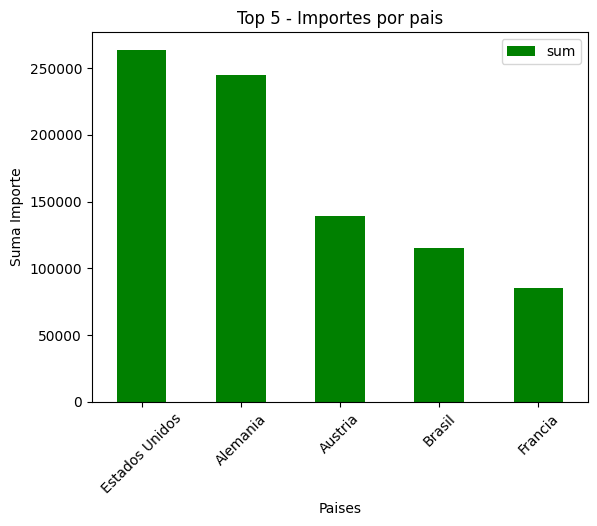

In [3]:
# Para usar matplotlib debo instalar la libreria externa, desde terminal pip install matplotlib

# 0. llamar a la libreria y a la clase

import matplotlib.pyplot as plt

# 1. Para crear un grafico debo reservar espacio en el kernel con figure

plt.figure(figsize=(12,6))

# 2. Crear el gráfico de columnas tipo break , kind = 'bar'

pedidos_agrupados_top5.plot(kind='bar', x='Pais', y='sum', color='green')

# 3. Ajustar parametros del grafico
plt.title("Top 5 - Importes por pais")          # Titulo del grafico
plt.xlabel("Paises")                            # Titulo eje x  
plt.ylabel("Suma Importe")                      # Titulo eje y  
plt.legend()
plt.xticks(rotation=45)                         # rota el titulo eje x 45º



# 3. Llamada al grafico.  plt.show()
plt.show()





<Figure size 1500x1500 with 0 Axes>

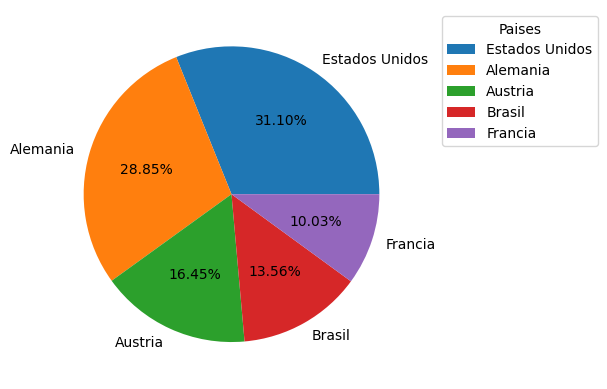

In [4]:
# Aprovechando el Top 5 vamos a ver un gráfico circular con kind='pie'


# 0. llamar a la libreria y a la clase

import matplotlib.pyplot as plt

# 1. Para crear un grafico debo reservar espacio en el kernel con figure

plt.figure(figsize=(15,15))

# 2. Crear el gráfico de pastel tipo break , kind = 'pie'

pedidos_agrupados_top5.plot(kind='pie', y='sum', labels=pedidos_agrupados_top5['Pais'], autopct='%1.2f%%')

# 3. Anclar leyenda a la parte derecha

plt.legend(title="Paises", bbox_to_anchor=(1.05,1))



# 3. Llamada al grafico.  plt.show()
plt.show()


Practica 10: Mediante el dataframe de pedidos agrupados, ver en un grafico circular los 3 paises que menos importe tienen, con sus % reales.
Si en el dataframe el % de un pais es el 15,38%, en el grafico tengo que ver
ese mismo porcentaje.
Pista!!! Si queremos los 3 que menos, necesitaremos 4 porciones.

In [ ]:
pedidos_agrupados_resto = pedidos_agrupados.nsmallest(3, "sum")

pedidos_agrupados_resto

,Pais,sum,mean,count
15,Polonia,3371.95,240.853571,14
14,Noruega,5735.15,358.446875,16
1,Argentina,8119.10,238.797059,34


<Figure size 1500x1500 with 0 Axes>

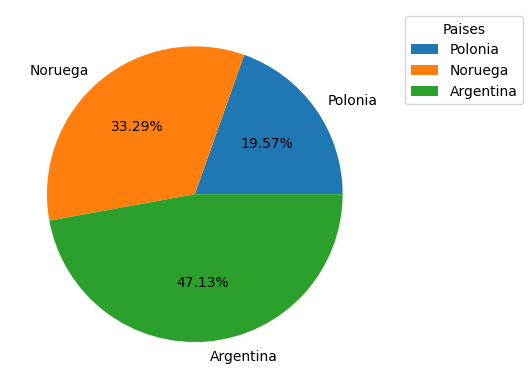

In [8]:
# 0. Importar las librerias necesarias
import pandas as pd

# 1. Ajustar la ruta del fichero excel

ruta_excel = "/Users/rogerdefez/Documents/Cursos i Llibres/Curso Barcelona Activa/2026-04-29_Python3_Ciencia-de-datos-Python-Institute-PCAD-31-Ed2/Datos_originales//Datos Pedidos.xlsx"

# 2. Cargar el DataFrame excel con los datos
pedidos = pd.read_excel(ruta_excel, sheet_name="Datos")

# 3. Crear la agrupacion por pais + suma importes

pedidos.groupby(['Pais'])['Importe'].sum()



type(pedidos.groupby(['Pais'])['Importe'].sum())



pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count'])



pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()


# Trabajar con una referencia a este dataframe
pedidos_agrupados = pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()



# 4. llamar a la libreria y a la clase

import matplotlib.pyplot as plt

pedidos_agrupados_top3 = pedidos_agrupados.nsmallest(3, "sum")
pedidos_agrupados_resto = pedidos_agrupados.nlargest(len(pedidos_agrupados)-3, "sum")

sum_resto = (pedidos_agrupados.nlargest(len(pedidos_agrupados)-3, "sum")['sum']).sum()

# 5. Para crear un grafico debo reservar espacio en el kernel con figure

plt.figure(figsize=(15,15))

# 6. Crear el gráfico de pastel tipo break , kind = 'pie'

pedidos_agrupados_top3.plot(kind='pie', y='sum', labels=pedidos_agrupados_top3['Pais'], autopct='%1.2f%%')


# 7. Anclar leyenda a la parte derecha

plt.legend(title="Paises", bbox_to_anchor=(1.05,1))



# 3. Llamada al grafico.  plt.show()
plt.show()

In [9]:
sum_resto


np.float64(1337232.3899999997)

In [ ]:
# SOLUCION PRACTICA 10


# 0. Importar las librerias necesarias
import pandas as pd

# 1. Ajustar la ruta del fichero excel

ruta_excel = "/Users/rogerdefez/Documents/Cursos i Llibres/Curso Barcelona Activa/2026-04-29_Python3_Ciencia-de-datos-Python-Institute-PCAD-31-Ed2/Datos_originales//Datos Pedidos.xlsx"

# 2. Cargar el DataFrame excel con los datos
pedidos = pd.read_excel(ruta_excel, sheet_name="Datos")

# 3. Crear la agrupacion por pais + suma importes

pedidos.groupby(['Pais'])['Importe'].sum()

type(pedidos.groupby(['Pais'])['Importe'].sum())

pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count'])

pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()


# Trabajar con una referencia a este dataframe
pedidos_agrupados = pedidos.groupby(['Pais'])['Importe'].agg(['sum','mean','count']).reset_index()



# 4. llamar a la libreria y a la clase

import matplotlib.pyplot as plt

pedidos_agrupados_top3 = pedidos_agrupados.nsmallest(3, "sum")




la suma total es 1354458.59
1337232.3899999997


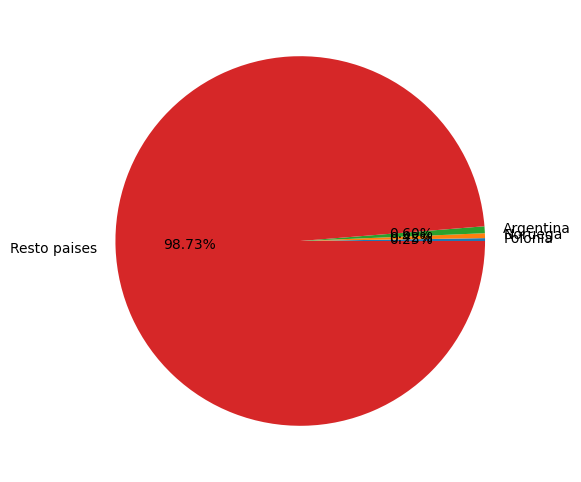

In [ ]:
# CONTINUACION SOLUCION PRACTICA 10

pedidos_agrupados
 
# Crear una columna con el % de la sum con respecto al total
# Almacenar en una variable la suma total

sum_total = round(pedidos_agrupados['sum'].sum(),2)

print('la suma total es', sum_total)

# 2. Crear una columna con el %!
pedidos_agrupados['% sum'] = round((pedidos_agrupados['sum'] / sum_total) * 100, 2)

#3. Mostrar el dataframe en orden descendente para ver los primeros %
pedidos_agrupados.sort_values(by = '% sum', ascending=True)

# 4. Que datos deberia ver:

# Polonia - 0,25%
# Noruega - 0,42
# Argentina - 0,60

# 5.  Guardar en un dataframe solo los 3 que menos (nlargest = los que más - nsmallest = los que menos)

pedidos_agrupados_3Men = pedidos_agrupados.nsmallest(3, "sum")
pedidos_agrupados_3Men

# 6. Guardar en un dataframe el resto de paises
pedidos_agrupados_resto = pedidos_agrupados.nlargest(len(pedidos_agrupados)-3, "sum")

#7 guardar en una variable la suma del resto
suma_resto = pedidos_agrupados_resto['sum'].sum()
print(suma_resto)

# 8. Crear un dataframe con los datos resto

pedidos_grafico = pd.DataFrame({
    "Pais": ["Resto paises"],
    "sum":[suma_resto]
})

# 9. Concatenar  Dataframe con los 3 que menois + el que contiene suma_resto
pedidos_grafico = pd.concat([pedidos_agrupados_3Men, pedidos_grafico], ignore_index=True)

# 10. vamos con el grafico 

# 11. Reservar la figure
plt.figure(figsize=(6,6))
plt.pie(pedidos_grafico['sum'], labels=pedidos_grafico['Pais'], autopct="%1.2f%%")

plt.show()

In [23]:
pedidos_agrupados_3Men.info()

<class 'pandas.DataFrame'>
Index: 3 entries, 15 to 1
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pais    3 non-null      str    
 1   sum     3 non-null      float64
 2   mean    3 non-null      float64
 3   count   3 non-null      int64  
 4   % sum   3 non-null      float64
dtypes: float64(3), int64(1), str(1)
memory usage: 168.0 bytes
